# Question 1 — descriptive analysis and borough clustering

This notebook has one role: describe the prepared panels and identify whether boroughs form a
stable, interpretable grouping. It does not fit forecasting or explanatory models. All rates use
the survey weights prepared in Notebook 01.

> **Primary limitation.** A borough-month has a small effective sample in many periods, so monthly
> borough estimates are exploratory. Quarterly pooling is shown alongside monthly data and is
> formally compared for forecasting in Notebook 03.


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler


warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 80)

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / 'question1_outputs').exists() else cwd.parent
OUTPUT_ROOT = PROJECT_ROOT / 'question1_outputs'
DATA_DIR = OUTPUT_ROOT / 'data'
RESULTS_DIR = OUTPUT_ROOT / 'results'
FIGURES_DIR = OUTPUT_ROOT / 'figures'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PATHS = {
    'london_annual': DATA_DIR / 'q1_london_annual.csv',
    'area_annual': DATA_DIR / 'q1_inner_outer_annual.csv',
    'borough_annual': DATA_DIR / 'q1_borough_annual.csv',
    'london_monthly': DATA_DIR / 'q1_london_monthly.csv',
    'area_monthly': DATA_DIR / 'q1_inner_outer_monthly.csv',
    'borough_monthly': DATA_DIR / 'q1_borough_monthly.csv',
    'borough_quarterly': DATA_DIR / 'q1_borough_quarterly.csv',
}
RESULTS_PATH = RESULTS_DIR / 'q1_descriptive_and_clustering.xlsx'
TARGETS = ['inactive_rate', 'fairly_active_rate', 'active_rate']
TARGET_LABELS = {
    'inactive_rate': 'Inactive',
    'fairly_active_rate': 'Fairly active',
    'active_rate': 'Active',
}
CONTEXT_FEATURES = [
    'adult_population', 'population_age_16_34_rate', 'population_age_65_plus_rate',
    'population_female_rate', 'net_migration_per_1000',
    'median_weekly_earnings_gbp', 'earnings_relative_to_london',
    'personal_safety_crime_rate_per_1000',
    'property_public_space_crime_rate_per_1000',
    'selected_recorded_crime_rate_per_1000',
]
RANDOM_STATE = 2026


def save_figure(fig, name):
    path = FIGURES_DIR / name
    fig.savefig(path, dpi=180, bbox_inches='tight', facecolor='white')
    return path


## 1. Load and validate the prepared panels

The seven panels are read from the single preparation output folder. Balanced dimensions and
complete outcome shares are checked before any figure or clustering result is produced.


In [2]:
panels = {name: pd.read_csv(path) for name, path in PATHS.items()}
for name in ['london_monthly', 'area_monthly', 'borough_monthly']:
    panels[name]['period_start'] = pd.to_datetime(panels[name]['period_start'])
panels['borough_quarterly']['quarter_start'] = pd.to_datetime(
    panels['borough_quarterly']['quarter_start']
)
panels['borough_quarterly']['quarter_end'] = pd.to_datetime(
    panels['borough_quarterly']['quarter_end']
)
globals().update(panels)

panel_inventory = pd.DataFrame([
    {
        'panel': name,
        'rows': len(frame),
        'columns': frame.shape[1],
        'geographies': frame['geography_code'].nunique(),
        'missing_outcomes': int(frame[TARGETS].isna().sum().sum()),
    }
    for name, frame in panels.items()
])
display(panel_inventory)
assert panel_inventory.loc[panel_inventory['panel'].ne('borough_monthly'), 'missing_outcomes'].eq(0).all()
assert panel_inventory.loc[
    panel_inventory['panel'].eq('borough_monthly'), 'missing_outcomes'
].iloc[0] <= len(TARGETS)
assert len(borough_monthly) == 32 * 96
assert len(borough_quarterly) == 32 * 32


,panel,rows,columns,geographies,missing_outcomes
0,london_annual,8,396,1,0
1,area_annual,16,397,2,0
2,borough_annual,256,397,32,0
3,london_monthly,96,401,1,0
4,area_monthly,192,402,2,0
5,borough_monthly,3072,402,32,3
6,borough_quarterly,1024,401,32,0


## 2. Precision at monthly, quarterly and annual frequency

Kish effective sample size is a precision diagnostic, not a formal suppression threshold. The
comparison below shows why individual borough-month results must be labelled exploratory and why
quarterly forecasting is a serious alternative rather than an arbitrary extra model.


,frequency,observations,median_effective_n,p25_effective_n,share_below_20,share_below_30
0,Monthly,3072,25.2,19.8,25.8%,69.3%
1,Quarterly,1024,71.5,61.9,0.2%,1.0%
2,Annual,256,294.7,280.8,0.0%,0.0%


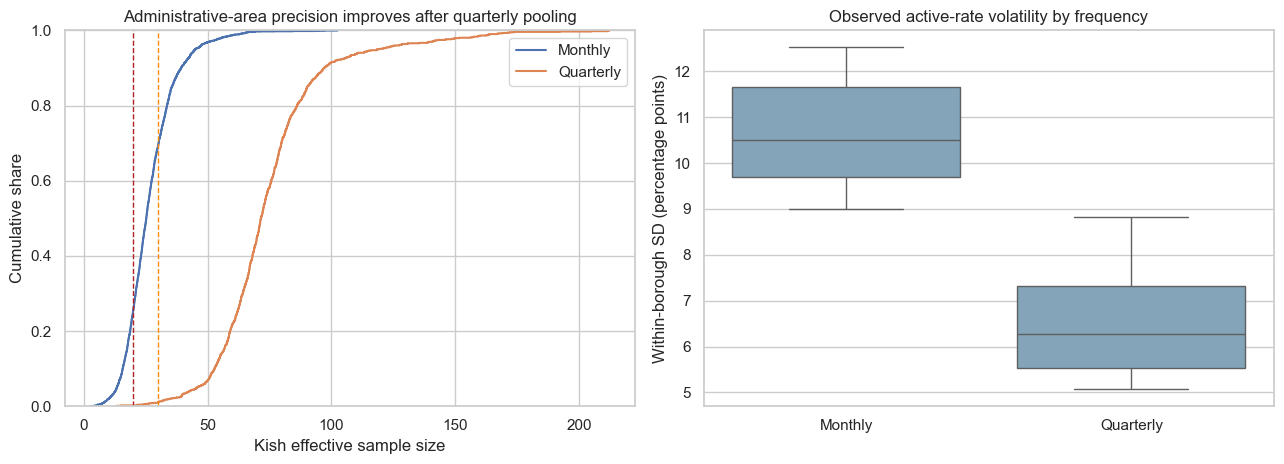

In [3]:
def precision_summary(frame, period_label):
    effective_n = frame['effective_n']
    return {
        'frequency': period_label,
        'observations': len(frame),
        'median_effective_n': effective_n.median(),
        'p25_effective_n': effective_n.quantile(.25),
        'share_below_20': effective_n.lt(20).mean(),
        'share_below_30': effective_n.lt(30).mean(),
    }


precision_table = pd.DataFrame([
    precision_summary(borough_monthly, 'Monthly'),
    precision_summary(borough_quarterly, 'Quarterly'),
    precision_summary(borough_annual, 'Annual'),
])
display(precision_table.style.format({
    'median_effective_n': '{:.1f}', 'p25_effective_n': '{:.1f}',
    'share_below_20': '{:.1%}', 'share_below_30': '{:.1%}',
}))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
sns.ecdfplot(borough_monthly['effective_n'], label='Monthly', ax=axes[0])
sns.ecdfplot(borough_quarterly['effective_n'], label='Quarterly', ax=axes[0])
axes[0].axvline(20, color='firebrick', linestyle='--', linewidth=1)
axes[0].axvline(30, color='darkorange', linestyle='--', linewidth=1)
axes[0].set(title='Administrative-area precision improves after quarterly pooling',
            xlabel='Kish effective sample size', ylabel='Cumulative share')
axes[0].legend()

monthly_sd = borough_monthly.groupby('geography_name')['active_rate'].std().rename('Monthly')
quarterly_sd = borough_quarterly.groupby('geography_name')['active_rate'].std().rename('Quarterly')
variability = pd.concat([monthly_sd, quarterly_sd], axis=1).mul(100).reset_index()
variability_long = variability.melt('geography_name', var_name='Frequency', value_name='SD')
sns.boxplot(data=variability_long, x='Frequency', y='SD', ax=axes[1], color='#7aa6c2')
axes[1].set(title='Observed active-rate volatility by frequency',
            xlabel='', ylabel='Within-borough SD (percentage points)')
fig.tight_layout()
save_figure(fig, 'sample_precision_monthly_vs_quarterly.png')
plt.show()


### Interpretation

Quarterly pooling increases the typical effective sample and visibly reduces within-borough
volatility. It cannot remove all survey error, but it offers a more stable decision scale while
retaining seasonal information. Annual results remain the strongest descriptive summary.


## 3. Annual and monthly activity patterns

The annual chart carries the main descriptive message. The monthly chart uses a centred
three-month rolling mean only for visualisation; modelling continues to use the original weighted
observations. The shaded region identifies the main COVID disruption period.


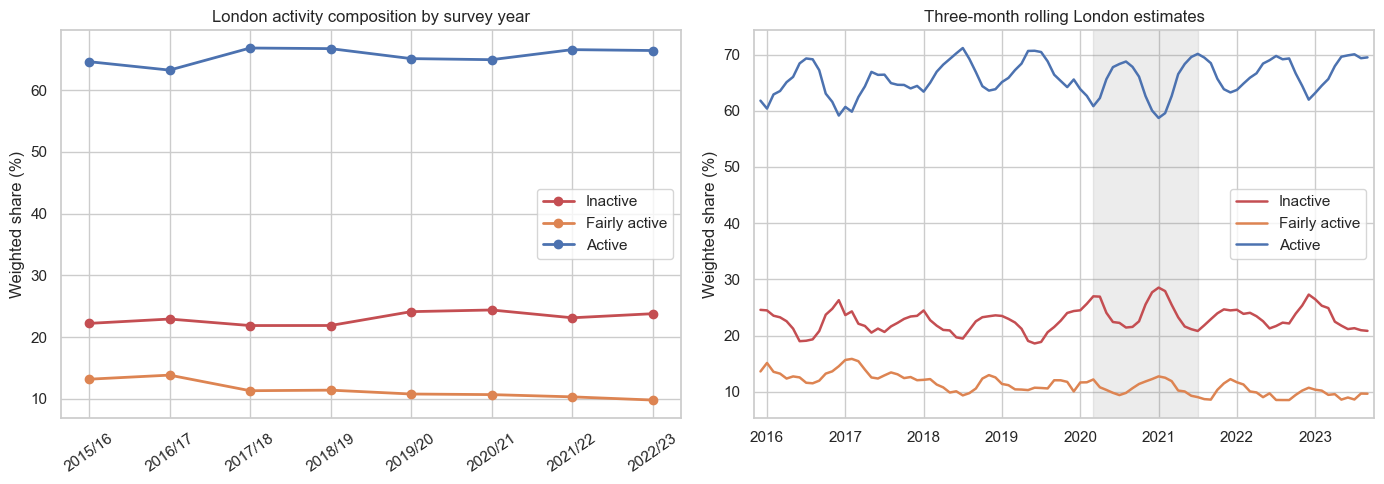

In [4]:
annual_plot = london_annual.set_index('survey_wave')[TARGETS].mul(100)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
annual_plot.plot(marker='o', linewidth=2, ax=axes[0], color=['#c44e52', '#dd8452', '#4c72b0'])
axes[0].set(title='London activity composition by survey year', xlabel='', ylabel='Weighted share (%)')
axes[0].tick_params(axis='x', rotation=35)
axes[0].legend([TARGET_LABELS[column] for column in TARGETS])

monthly_london = london_monthly.set_index('period_start')[TARGETS].rolling(3, center=True).mean().mul(100)
monthly_london.plot(ax=axes[1], linewidth=1.8, color=['#c44e52', '#dd8452', '#4c72b0'])
axes[1].axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-07-01'), color='grey', alpha=.15)
axes[1].set(title='Three-month rolling London estimates', xlabel='', ylabel='Weighted share (%)')
axes[1].legend([TARGET_LABELS[column] for column in TARGETS])
fig.tight_layout()
save_figure(fig, 'activity_trends_annual_and_monthly.png')
plt.show()


## 4. External context used in the analysis

Only the three retained sources appear here: population/migration, resident earnings and selected
recorded crime. Correlations are descriptive and do not establish causal effects. Crime is kept as
a potentially informative but specification-sensitive contextual measure.


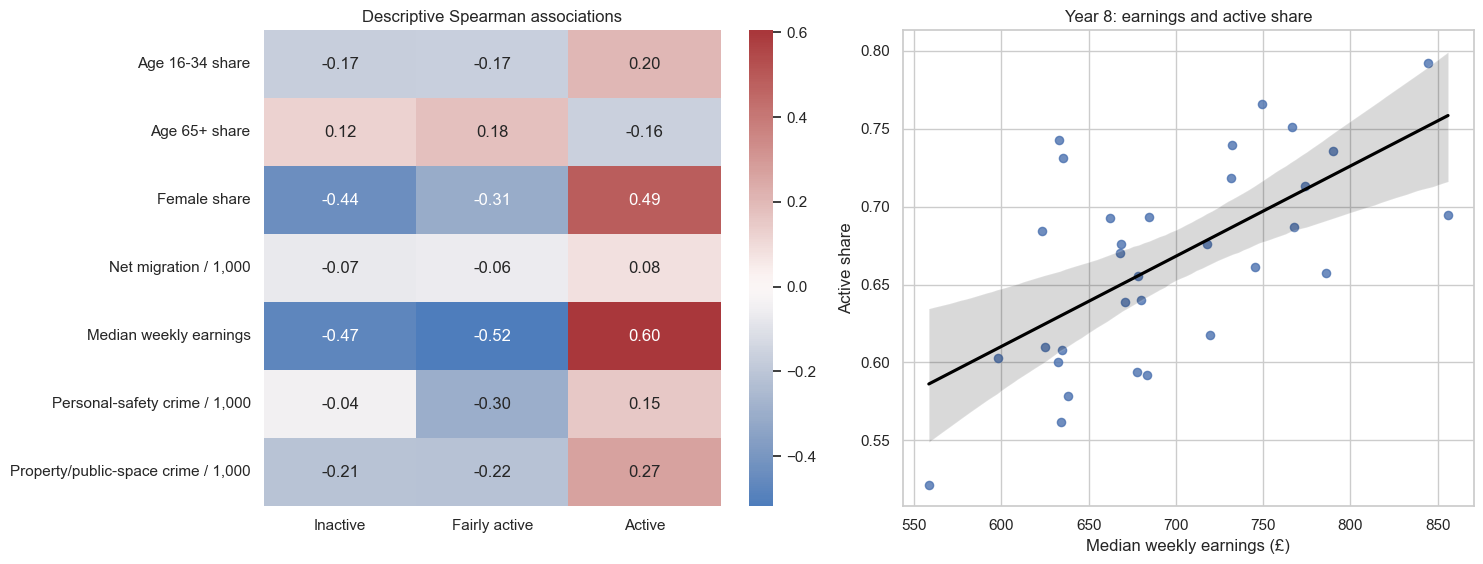

In [5]:
context_labels = {
    'population_age_16_34_rate': 'Age 16-34 share',
    'population_age_65_plus_rate': 'Age 65+ share',
    'population_female_rate': 'Female share',
    'net_migration_per_1000': 'Net migration / 1,000',
    'median_weekly_earnings_gbp': 'Median weekly earnings',
    'personal_safety_crime_rate_per_1000': 'Personal-safety crime / 1,000',
    'property_public_space_crime_rate_per_1000': 'Property/public-space crime / 1,000',
}
context_view = borough_annual[[*context_labels, *TARGETS]].corr(method='spearman').loc[
    list(context_labels), TARGETS
]
context_view.index = [context_labels[index] for index in context_view.index]
context_view.columns = [TARGET_LABELS[column] for column in context_view.columns]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))
sns.heatmap(context_view, annot=True, fmt='.2f', cmap='vlag', center=0, ax=axes[0])
axes[0].set_title('Descriptive Spearman associations')
latest = borough_annual.loc[borough_annual['year'].eq(8)]
sns.regplot(data=latest, x='median_weekly_earnings_gbp', y='active_rate', ax=axes[1],
            scatter_kws={'s': 35, 'alpha': .8}, line_kws={'color': 'black'})
axes[1].set(title='Year 8: earnings and active share', xlabel='Median weekly earnings (£)',
            ylabel='Active share')
fig.tight_layout()
save_figure(fig, 'external_context_descriptive_associations.png')
plt.show()


## 5. Rigorous borough clustering

Clusters use Years 1–6 only, protecting later validation and test periods. Highly redundant raw
activity variables are represented by three transparent family means; outcomes, survey
composition and the retained context complete the profile. Features are standardised and PCA
retains 90% of their variance.

K-means and Ward clustering are compared for 2–8 clusters. Selection combines silhouette,
Calinski–Harabasz, Davies–Bouldin and year-bootstrap adjusted Rand stability, while rejecting any
solution with fewer than four boroughs in a cluster.


In [6]:
activity_groups = {
    'activity_months12_mean': [column for column in borough_annual if column.startswith('MONTHS12_RATE_')],
    'activity_days_any_mean': [column for column in borough_annual if column.startswith('DAYS_ANY_RATE_')],
    'activity_days_2plus_mean': [column for column in borough_annual if column.startswith('DAYS_2PLUS_RATE_')],
}
cluster_panel = borough_annual.loc[borough_annual['year'].between(1, 6)].copy()
for feature, columns in activity_groups.items():
    cluster_panel[feature] = cluster_panel[columns].mean(axis=1)

cluster_features = [
    *TARGETS, 'older_adult_rate', 'limiting_disability_rate', 'online_response_rate',
    'population_age_16_34_rate', 'population_age_65_plus_rate',
    'net_migration_per_1000', 'median_weekly_earnings_gbp',
    'personal_safety_crime_rate_per_1000',
    'property_public_space_crime_rate_per_1000',
    'selected_recorded_crime_rate_per_1000',
    *activity_groups,
]
profile = cluster_panel.groupby(['geography_code', 'geography_name', 'inner_outer'], as_index=False)[
    cluster_features
].mean()
scaler = StandardScaler()
scaled_profile = scaler.fit_transform(profile[cluster_features])
pca = PCA(n_components=.90, random_state=RANDOM_STATE)
profile_scores = pca.fit_transform(scaled_profile)


def fit_labels(method, k, values, seed=RANDOM_STATE):
    if method == 'K-means':
        return KMeans(n_clusters=k, n_init=20, random_state=seed).fit_predict(values)
    return AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(values)


def bootstrap_stability(method, k, base_labels, repeats=60):
    rng = np.random.default_rng(RANDOM_STATE + k)
    scores = []
    years = np.arange(1, 7)
    for repeat in range(repeats):
        sampled = rng.choice(years, size=len(years), replace=True)
        pieces = [cluster_panel.loc[cluster_panel['year'].eq(year)] for year in sampled]
        boot = pd.concat(pieces).groupby('geography_code')[cluster_features].mean().reindex(
            profile['geography_code']
        )
        boot_scaled = scaler.transform(boot)
        boot_scores = pca.transform(boot_scaled)
        labels = fit_labels(method, k, boot_scores, seed=RANDOM_STATE + repeat)
        scores.append(adjusted_rand_score(base_labels, labels))
    return float(np.median(scores)), float(np.quantile(scores, .10))


candidate_rows = []
for method in ['K-means', 'Ward']:
    for k in range(2, 9):
        labels = fit_labels(method, k, profile_scores)
        counts = pd.Series(labels).value_counts()
        stability_median, stability_p10 = bootstrap_stability(method, k, labels)
        candidate_rows.append({
            'method': method, 'clusters': k,
            'silhouette': silhouette_score(profile_scores, labels),
            'calinski_harabasz': calinski_harabasz_score(profile_scores, labels),
            'davies_bouldin': davies_bouldin_score(profile_scores, labels),
            'stability_median_ari': stability_median,
            'stability_p10_ari': stability_p10,
            'smallest_cluster': int(counts.min()),
        })

cluster_candidates = pd.DataFrame(candidate_rows)
eligible = cluster_candidates['smallest_cluster'].ge(4)
for column, direction in [
    ('silhouette', 1), ('calinski_harabasz', 1), ('davies_bouldin', -1),
    ('stability_median_ari', 1), ('stability_p10_ari', 1),
]:
    values = cluster_candidates.loc[eligible, column]
    scale = values.std(ddof=0) or 1
    cluster_candidates.loc[eligible, f'z_{column}'] = direction * (values - values.mean()) / scale
score_columns = [column for column in cluster_candidates if column.startswith('z_')]
cluster_candidates['selection_score'] = cluster_candidates[score_columns].mean(axis=1)
winner = cluster_candidates.loc[eligible].sort_values(
    ['selection_score', 'stability_median_ari', 'silhouette'], ascending=False
).iloc[0]
selected_method, selected_k = winner['method'], int(winner['clusters'])
profile['cluster_id'] = fit_labels(selected_method, selected_k, profile_scores) + 1

cluster_means = profile.groupby('cluster_id')[cluster_features].mean()
cluster_order = cluster_means['active_rate'].sort_values().index
cluster_names = {cluster_id: f'C{rank}: {"higher" if rank == selected_k else "lower" if rank == 1 else "mid"} activity'
                 for rank, cluster_id in enumerate(cluster_order, start=1)}
profile['cluster_label'] = profile['cluster_id'].map(cluster_names)
inner_outer_codes = profile['inner_outer'].astype('category').cat.codes
inner_outer_ari = adjusted_rand_score(inner_outer_codes, profile['cluster_id'])

pca_coordinates = profile[['geography_code', 'geography_name', 'inner_outer', 'cluster_id', 'cluster_label']].copy()
pca_coordinates['PC1'] = profile_scores[:, 0]
pca_coordinates['PC2'] = profile_scores[:, 1]
display(cluster_candidates.sort_values('selection_score', ascending=False).head(10))
display(
    profile.sort_values(['cluster_id', 'geography_name'])[
        ['geography_name', 'inner_outer', 'cluster_label']
    ]
)
print(f'Selected: {selected_method}, k={selected_k}; Inner/Outer ARI={inner_outer_ari:.3f}')


,method,clusters,silhouette,calinski_harabasz,davies_bouldin,stability_median_ari,stability_p10_ari,smallest_cluster,z_silhouette,z_calinski_harabasz,z_davies_bouldin,z_stability_median_ari,z_stability_p10_ari,selection_score
0,K-means,2,0.359016,18.895186,1.123157,0.874984,0.455681,13,1.182762,1.007757,0.532546,1.199675,0.427444,0.870037
7,Ward,2,0.324565,17.829700,1.083152,0.758190,0.167542,14,0.080040,0.355376,0.868317,0.048687,-1.381185,-0.005753
8,Ward,3,0.282613,15.022983,1.353516,0.626576,0.539526,9,-1.262802,-1.363134,-1.400864,-1.248362,0.953740,-0.864284
1,K-means,3,0.374352,15.310326,1.025290,0.638563,0.445107,3,NaN,NaN,NaN,NaN,NaN,NaN
2,K-means,4,0.316836,16.192440,0.976797,0.812328,0.640357,1,NaN,NaN,NaN,NaN,NaN,NaN
3,K-means,5,0.264910,14.906346,1.028301,0.498014,0.430412,3,NaN,NaN,NaN,NaN,NaN,NaN
4,K-means,6,0.279441,15.887389,0.813699,0.563385,0.424440,1,NaN,NaN,NaN,NaN,NaN,NaN
5,K-means,7,0.299622,17.460919,0.719456,0.730412,0.536690,1,NaN,NaN,NaN,NaN,NaN,NaN
6,K-means,8,0.294320,17.848951,0.737219,0.597368,0.445466,1,NaN,NaN,NaN,NaN,NaN,NaN
9,Ward,4,0.308162,16.098813,0.990197,0.638252,0.468277,1,NaN,NaN,NaN,NaN,NaN,NaN


,geography_name,inner_outer,cluster_label
0,Barking and Dagenham,Outer London,C1: lower activity
1,Barnet,Outer London,C1: lower activity
2,Bexley,Outer London,C1: lower activity
3,Brent,Outer London,C1: lower activity
4,Bromley,Outer London,C1: lower activity
6,Croydon,Outer London,C1: lower activity
7,Ealing,Outer London,C1: lower activity
8,Enfield,Outer London,C1: lower activity
9,Greenwich,Outer London,C1: lower activity
13,Harrow,Outer London,C1: lower activity


Selected: K-means, k=2; Inner/Outer ARI=0.758


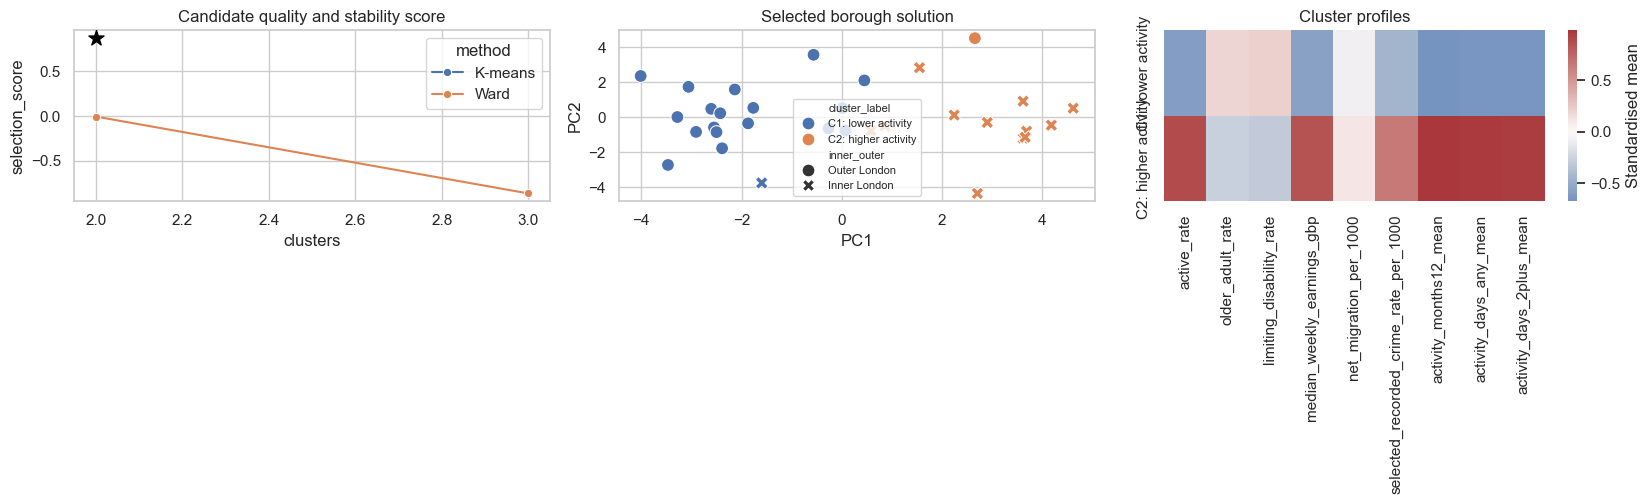

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))
sns.lineplot(data=cluster_candidates, x='clusters', y='selection_score', hue='method', marker='o', ax=axes[0])
axes[0].scatter([selected_k], [winner['selection_score']], s=130, marker='*', color='black', zorder=5)
axes[0].set_title('Candidate quality and stability score')

sns.scatterplot(data=pca_coordinates, x='PC1', y='PC2', hue='cluster_label', style='inner_outer',
                s=85, ax=axes[1])
axes[1].set_title('Selected borough solution')
axes[1].legend(fontsize=8, loc='best')

heat_features = [
    'active_rate', 'older_adult_rate', 'limiting_disability_rate',
    'median_weekly_earnings_gbp', 'net_migration_per_1000',
    'selected_recorded_crime_rate_per_1000', *activity_groups,
]
heat = profile.groupby('cluster_label')[heat_features].mean()
heat = (heat - profile[heat_features].mean()) / profile[heat_features].std(ddof=0)
sns.heatmap(heat, cmap='vlag', center=0, ax=axes[2], cbar_kws={'label': 'Standardised mean'})
axes[2].set_title('Cluster profiles')
axes[2].set_xlabel('')
axes[2].set_ylabel('')
fig.tight_layout()
save_figure(fig, 'borough_cluster_selection_and_profiles.png')
plt.show()


### Interpretation

The selected solution is a descriptive typology, not a causal classification. Its adjusted Rand
agreement with Inner/Outer London is reported explicitly. Because the group’s parallel work
already covers Inner/Outer forecasting, this notebook deliberately stops at borough assignment
and does not add a cluster-level forecast.


## 6. Compact delivery

All numerical descriptive and clustering outputs are stored as sheets in one workbook. The four
main visual arguments are saved as publication-ready PNG files in the shared figures folder.


In [8]:
cluster_summary = profile.groupby(['cluster_id', 'cluster_label'], as_index=False).agg(
    boroughs=('geography_code', 'size'),
    active_rate=('active_rate', 'mean'),
    inactive_rate=('inactive_rate', 'mean'),
    median_weekly_earnings_gbp=('median_weekly_earnings_gbp', 'mean'),
    selected_recorded_crime_rate_per_1000=('selected_recorded_crime_rate_per_1000', 'mean'),
)
decision_register = pd.DataFrame([
    {'decision': 'External data', 'result': 'Population/migration, resident earnings and selected recorded crime only'},
    {'decision': 'Monthly borough inference', 'result': 'Exploratory because many effective samples remain small'},
    {'decision': 'Quarterly borough inference', 'result': 'Primary alternative evaluated in Notebook 03'},
    {'decision': 'Cluster method', 'result': f'{selected_method}, k={selected_k}'},
    {'decision': 'Inner/Outer equivalence', 'result': f'ARI={inner_outer_ari:.3f}; no cluster-level forecast is added'},
])

with pd.ExcelWriter(RESULTS_PATH, engine='openpyxl') as writer:
    panel_inventory.to_excel(writer, sheet_name='panel_inventory', index=False)
    precision_table.to_excel(writer, sheet_name='precision_summary', index=False)
    annual_plot.reset_index().to_excel(writer, sheet_name='london_annual_trend', index=False)
    context_view.reset_index(names='context_feature').to_excel(writer, sheet_name='context_correlations', index=False)
    cluster_candidates.to_excel(writer, sheet_name='cluster_candidates', index=False)
    profile.to_excel(writer, sheet_name='borough_assignments', index=False)
    cluster_summary.to_excel(writer, sheet_name='cluster_summary', index=False)
    pca_coordinates.to_excel(writer, sheet_name='cluster_coordinates', index=False)
    decision_register.to_excel(writer, sheet_name='decision_register', index=False)

print(f'Wrote {RESULTS_PATH.relative_to(PROJECT_ROOT)}')


Wrote question1_outputs\results\q1_descriptive_and_clustering.xlsx
